### AGENDA
The previous perturbation-buffering notebook was a useful first pass, but it tested the question in a way that was likely too coarse. Specifically, it reduced compensation into a single summary statistic by averaging responses across all chaperone-rich modules and then asking whether deletions from one module globally activated that combined score more than deletions from other modules. That approach may have hidden biologically meaningful structure, because compensation is unlikely to occur as a uniform module-wide effect. Instead, buffering is more plausibly specific to particular module pairs or subsets of highly responsive deletions. In this notebook, we therefore shift from a one-dimensional “chaperone activation score” to a module-to-module response framework. For each deletion module, we will measure how every other module responds, identify pairwise compensation patterns, and ask whether perturbation in one community is associated with reproducible upregulation or downregulation in another. This approach is better aligned with the biological hypothesis that buffering operates through specific cross-module relationships rather than broad global activation of proteostasis modules.

In [1]:
# ============================================================
# CELL 1: IMPORTS AND HELPER FUNCTIONS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
from tqdm.auto import tqdm

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


def compute_module_averages(proteome_df, protein_to_module, modules):
    """
    Compute mean fold-change for each module across all deletions.

    Parameters
    ----------
    proteome_df : DataFrame
        Rows = deleted ORFs
        Columns = proteins (ORFs)
        Values = fold-change (fc)

    protein_to_module : dict
        protein ORF -> module ID

    modules : list
        all module IDs

    Returns
    -------
    module_avgs : DataFrame
        Rows = deleted ORFs
        Columns = module IDs
        Values = mean fc of proteins in that module
    """
    module_to_proteins = {m: [] for m in modules}

    for protein, module in protein_to_module.items():
        if module in module_to_proteins:
            module_to_proteins[module].append(protein)

    module_avgs = pd.DataFrame(index=proteome_df.index, columns=modules, dtype=float)

    for m in modules:
        proteins_in_module = [p for p in module_to_proteins[m] if p in proteome_df.columns]
        if len(proteins_in_module) > 0:
            module_avgs[m] = proteome_df[proteins_in_module].mean(axis=1)
        else:
            module_avgs[m] = np.nan

    return module_avgs


def standardize_rows(df):
    """
    Z-score each row independently.
    Useful for asking which modules are relatively high or low
    within each deletion profile.
    """
    row_means = df.mean(axis=1)
    row_stds = df.std(axis=1).replace(0, np.nan)
    return df.sub(row_means, axis=0).div(row_stds, axis=0)

In [2]:
# ============================================================
# CELL 2: LOAD INTERACTOME + COMMUNITY MAP
# ============================================================

nodes_path = "../../18-finalize/processed-data/20260210-s288c-ANnnotated-Yeast-Interactome.pkl"
community_map_path = "../../18-finalize/processed-data/community_map.pkl"

nodes_df = pd.read_pickle(nodes_path)
community_map = pd.read_pickle(community_map_path)

# Identify chaperones
all_chaperones = set()
for lst in nodes_df["interacting_chaperones"]:
    if isinstance(lst, (list, set, tuple)):
        all_chaperones.update(lst)

nodes_df["is_chaperone"] = nodes_df["node"].isin(all_chaperones)

# protein ORF -> module
protein_to_module = {
    row["node"]: community_map.get(row["node"], None)
    for _, row in nodes_df.iterrows()
}

modules = sorted(set(community_map.values()))

print("Number of modules:", len(modules))
print("Example modules:", modules[:10])

Number of modules: 30
Example modules: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [5]:
# ============================================================
# CELL 3: LOAD CLEANED PROTEOME MATRIX
# ============================================================

# If you saved the cleaned matrix from notebook 05, load it:
proteome_matrix_path = "../../18-finalize/processed-data/yeast5k_fc_cleaned.pkl"

proteome_df = pd.read_pickle(proteome_matrix_path)

print("Proteome matrix shape:", proteome_df.shape)
print("First 10 deletions:", proteome_df.index[:10].tolist())
print("First 10 proteins:", proteome_df.columns[:10].tolist())

Proteome matrix shape: (2510, 1850)
First 10 deletions: ['YAL002W', 'YAL005C', 'YAL007C', 'YAL010C', 'YAL011W', 'YAL013W', 'YAL017W', 'YAL019W', 'YAL020C', 'YAL021C']
First 10 proteins: ['YPR010C-A', 'D6VTK4', 'O13297', 'O13516', 'O13563', 'O14455', 'O14467', 'YBR085C-A', 'O74700', 'P00128']


In [6]:
# ============================================================
# CELL 4: KEEP ONLY DELETIONS PRESENT IN COMMUNITY MAP
# ============================================================

valid_deletions = [orf for orf in proteome_df.index if orf in community_map]
proteome_df = proteome_df.loc[valid_deletions].copy()

print("Proteome matrix after restricting deletions:", proteome_df.shape)
print("Deletions in community_map:", len(valid_deletions))

Proteome matrix after restricting deletions: (2510, 1850)
Deletions in community_map: 2510


In [7]:
# ============================================================
# CELL 5: COMPUTE MODULE-LEVEL RESPONSES
# ============================================================

module_avg_df = compute_module_averages(proteome_df, protein_to_module, modules)

# add deletion module
module_avg_df["deletion_module"] = [community_map[orf] for orf in module_avg_df.index]

print(module_avg_df.shape)
module_avg_df.head()

(2510, 31)


,0,1,2,3,4,5,6,7,8,9,...,21,22,23,24,25,26,27,28,29,deletion_module
orf,,,,,,,,,,,,,,,,,,,,,
YAL002W,1.439528,1.461760,0.929759,1.039678,1.012634,1.336118,NaN,NaN,0.998465,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
YAL005C,0.953445,1.096046,1.064911,0.948788,0.960191,0.937099,NaN,NaN,1.042415,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
YAL007C,1.030336,1.260866,0.955657,1.039014,1.088000,1.090821,NaN,NaN,1.171171,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
YAL010C,0.896672,0.938822,0.960594,0.933718,0.887217,0.979563,NaN,NaN,0.861362,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
YAL011W,0.984620,1.049097,1.066416,1.009443,0.861109,1.133766,NaN,NaN,1.069924,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2


In [8]:
# ============================================================
# CELL 6: RAW MODULE-TO-MODULE RESPONSE MATRIX
#For deletions from module A, what is the average response in module B?
# ============================================================

response_matrix = pd.DataFrame(index=modules, columns=modules, dtype=float)

for deletion_module in modules:
    subset = module_avg_df[module_avg_df["deletion_module"] == deletion_module]
    if len(subset) == 0:
        continue
    for target_module in modules:
        response_matrix.loc[deletion_module, target_module] = subset[target_module].mean()

response_matrix

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
0,1.000652,0.992577,0.990652,0.998026,0.997623,1.007639,NaN,NaN,0.990009,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.998948,0.994446,0.992416,1.002904,0.991265,1.015086,NaN,NaN,0.985788,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.988333,1.008342,0.978554,1.005433,0.954938,1.044973,NaN,NaN,1.012828,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.986951,0.977769,0.990133,0.988289,0.983705,0.995517,NaN,NaN,0.965952,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.981771,0.988051,0.995105,1.013119,0.967758,1.013473,NaN,NaN,1.005619,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,0.988943,1.013129,0.990882,1.000440,0.958671,0.990574,NaN,NaN,1.001518,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,1.011746,1.045377,0.967713,0.977337,1.050656,1.053737,NaN,NaN,0.972657,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,1.009079,1.006737,0.979906,0.996092,1.013814,1.030360,NaN,NaN,0.926964,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,1.013121,1.026892,0.993928,1.022034,1.006989,1.055177,NaN,NaN,0.947050,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,0.979524,1.020012,1.027298,0.999238,0.969373,0.983188,NaN,NaN,1.004218,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


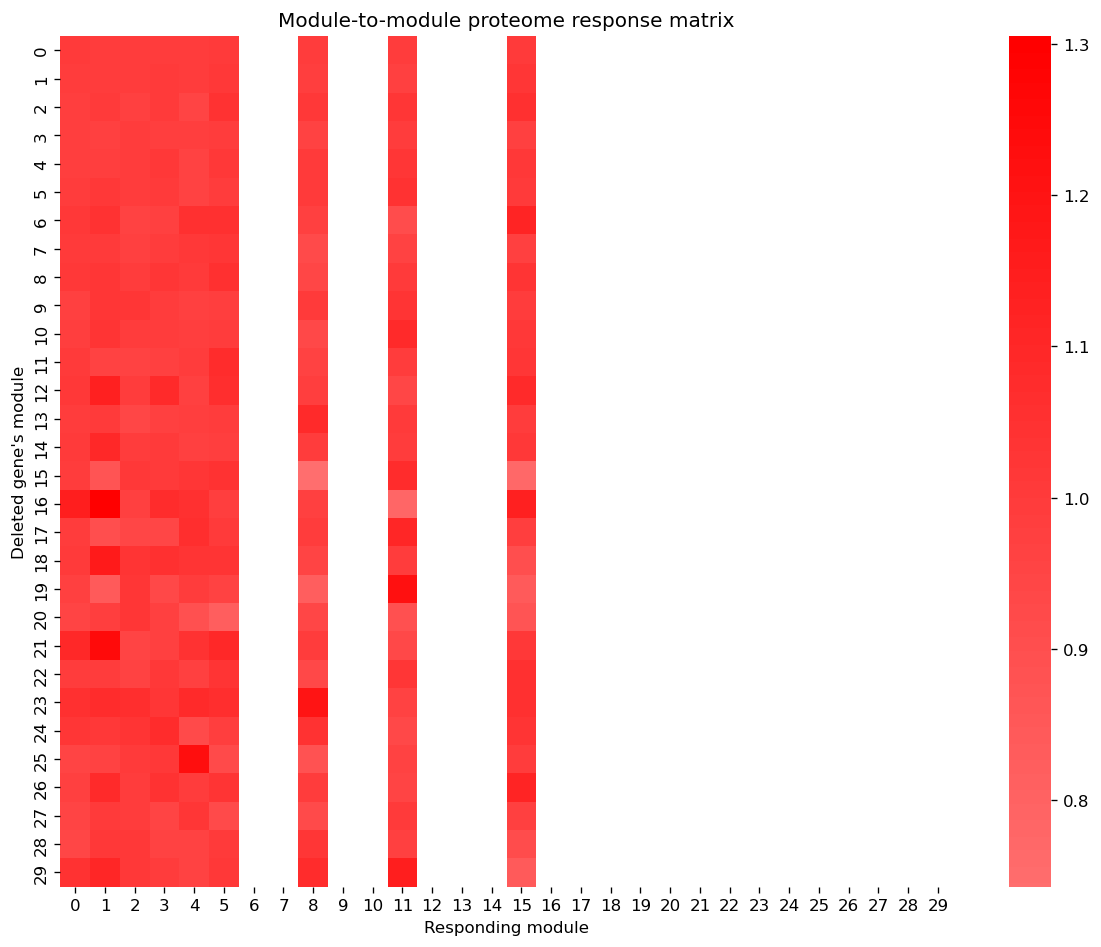

In [9]:
# ============================================================
# CELL 7: HEATMAP OF RAW MODULE-TO-MODULE RESPONSES
# ============================================================

plt.figure(figsize=(10, 8))
sns.heatmap(response_matrix, cmap="bwr", center=0)
plt.xlabel("Responding module")
plt.ylabel("Deleted gene's module")
plt.title("Module-to-module proteome response matrix")
plt.tight_layout()
plt.show()

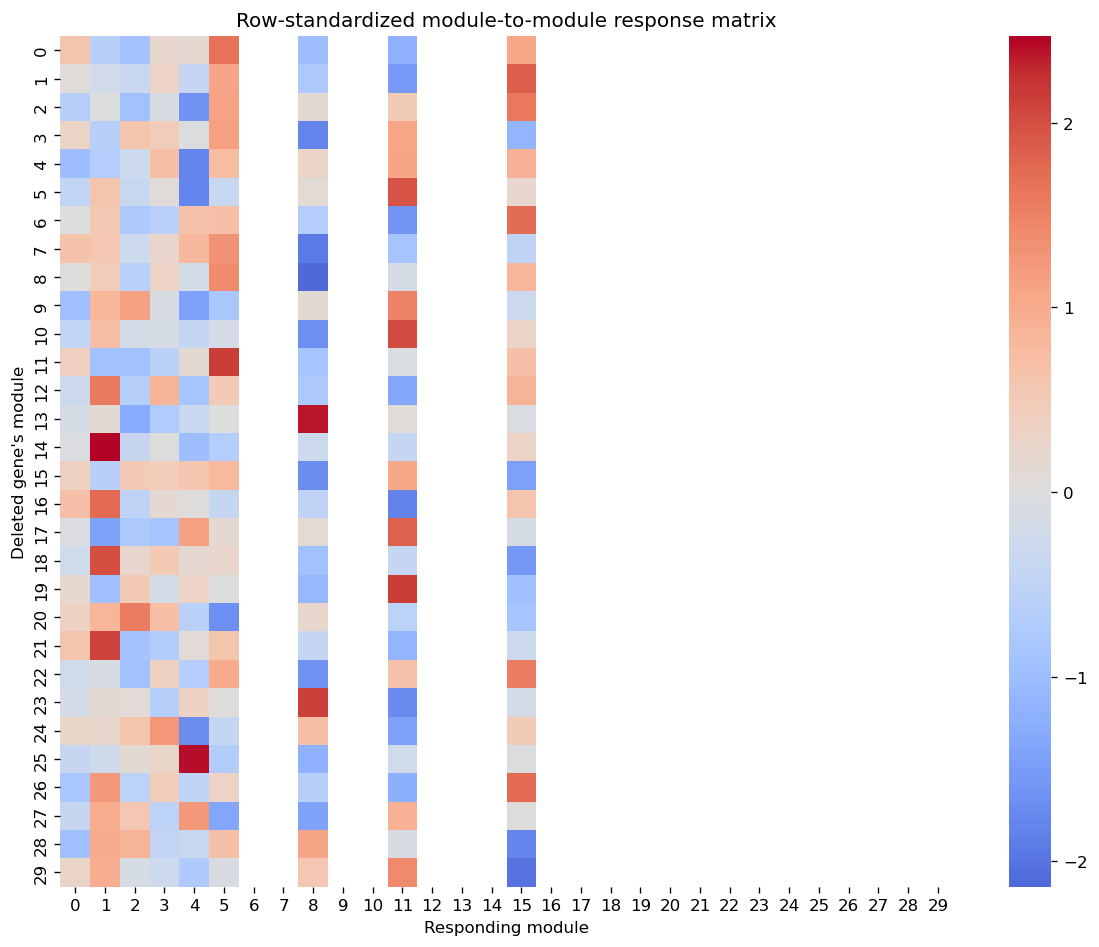

In [10]:
# ============================================================
# CELL 8: RELATIVE MODULE RESPONSE MATRIX
# ============================================================

response_matrix_z = standardize_rows(response_matrix)

plt.figure(figsize=(10, 8))
sns.heatmap(response_matrix_z, cmap="coolwarm", center=0)
plt.xlabel("Responding module")
plt.ylabel("Deleted gene's module")
plt.title("Row-standardized module-to-module response matrix")
plt.tight_layout()
plt.show()

Interpretation:
- positive = module is relatively more activated than others for that deletion class
- negative = relatively more suppressed
- This is much more informative than the raw matrix.
- some modules repeatedly act as response/buffering modules when other modules are perturbed.

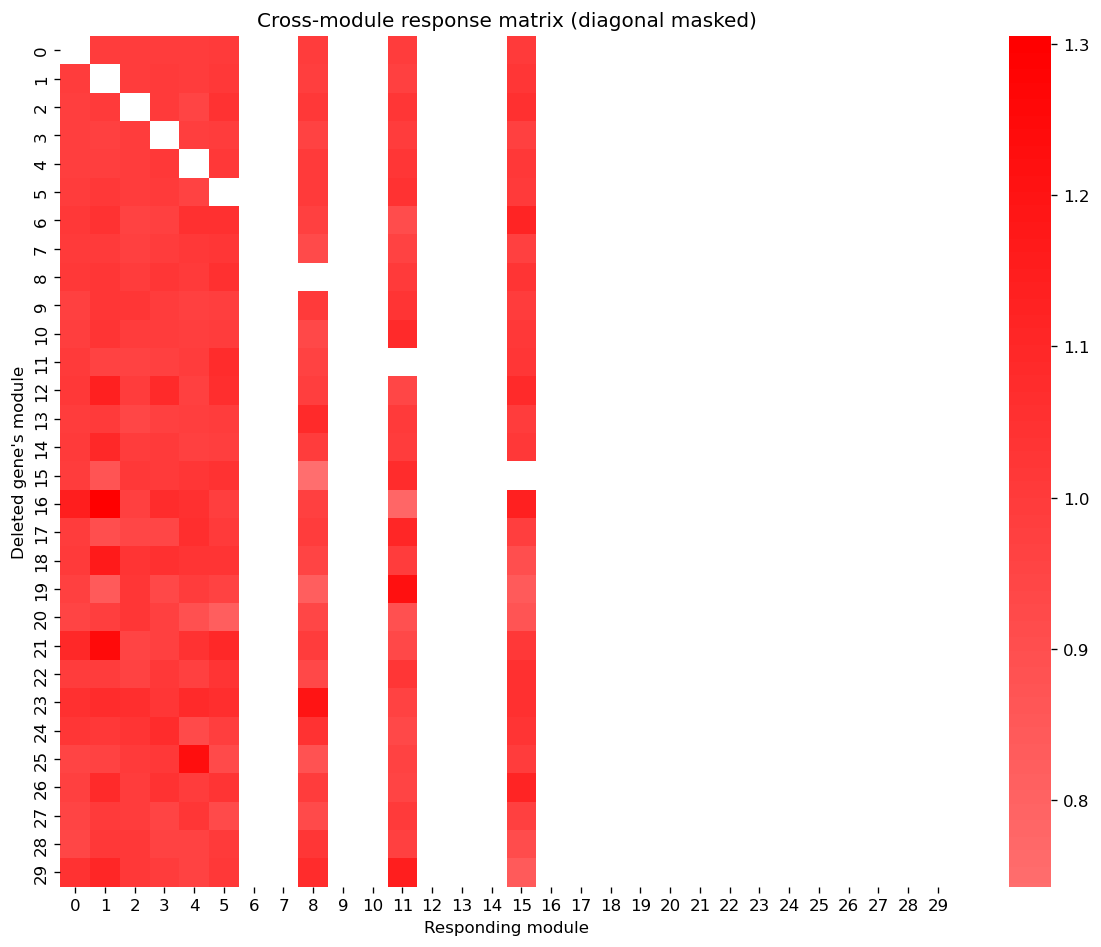

In [11]:
# ============================================================
# CELL 9: MASK DIAGONAL TO FOCUS ON CROSS-MODULE RESPONSES
# ============================================================

cross_module_matrix = response_matrix.copy()

for m in modules:
    cross_module_matrix.loc[m, m] = np.nan

plt.figure(figsize=(10, 8))
sns.heatmap(cross_module_matrix, cmap="bwr", center=0)
plt.xlabel("Responding module")
plt.ylabel("Deleted gene's module")
plt.title("Cross-module response matrix (diagonal masked)")
plt.tight_layout()
plt.show()

In [12]:
# ============================================================
# CELL 10: STRONGEST CANDIDATE COMPENSATION PAIRS
# ============================================================

pairs = []

for deletion_module in modules:
    subset = module_avg_df[module_avg_df["deletion_module"] == deletion_module]
    if len(subset) == 0:
        continue

    for target_module in modules:
        if deletion_module == target_module:
            continue

        vals = subset[target_module].dropna()
        if len(vals) == 0:
            continue

        pairs.append({
            "deletion_module": deletion_module,
            "target_module": target_module,
            "mean_response": vals.mean(),
            "median_response": vals.median(),
            "n_deletions": len(vals)
        })

pairs_df = pd.DataFrame(pairs)

# strongest positive responses
top_positive_pairs = pairs_df.sort_values("mean_response", ascending=False).head(20)
top_positive_pairs

,deletion_module,target_module,mean_response,median_response,n_deletions
136,16,1,1.305478,1.263430,6
181,21,1,1.246227,1.150402,4
220,25,4,1.228240,1.122880,4
169,19,11,1.221607,1.137011,5
204,23,8,1.196855,1.076680,4
154,18,1,1.167351,0.975950,5
259,29,11,1.150981,1.150981,1
135,16,0,1.148563,1.158187,6
143,16,15,1.141146,1.101208,6
101,12,1,1.131762,1.128793,9


- when genes from module 16 are deleted, module 1 tends to be upregulated
- when genes from module 19 are deleted, module 11 tends to be upregulated
- when genes from module 6 are deleted, module 15 tends to be upregulated

- That is already the compensation story in module language. Especially important pattern. Some target modules appear again and again: module 1, module 11, module 15

That suggests these modules may behave as buffering / response modules.

In [13]:
# ============================================================
# CELL 11: STRONGEST CANDIDATE SUPPRESSION PAIRS
# ============================================================

top_negative_pairs = pairs_df.sort_values("mean_response", ascending=True).head(20)
top_negative_pairs

,deletion_module,target_module,mean_response,median_response,n_deletions
133,15,8,0.742498,0.658491,5
142,16,11,0.777808,0.802269,6
176,20,5,0.823909,0.877632,4
168,19,8,0.825308,0.794293,5
170,19,15,0.841055,0.836682,5
163,19,1,0.841687,0.813201,5
260,29,15,0.844963,0.844963,1
179,20,15,0.873846,0.975849,4
128,15,1,0.874084,0.967674,5
222,25,8,0.876917,1.000000,4


These are coordinated decline relationships.

In [14]:
# ============================================================
# CELL 12: PAIRWISE STATISTICAL TESTS
# ============================================================

pair_stats = []

for deletion_module in modules:
    in_group = module_avg_df[module_avg_df["deletion_module"] == deletion_module]
    out_group = module_avg_df[module_avg_df["deletion_module"] != deletion_module]

    if len(in_group) < 5:
        continue

    for target_module in modules:
        if deletion_module == target_module:
            continue

        vals_in = in_group[target_module].dropna()
        vals_out = out_group[target_module].dropna()

        if len(vals_in) < 5 or len(vals_out) < 5:
            continue

        stat, p = mannwhitneyu(vals_in, vals_out, alternative="two-sided")

        pair_stats.append({
            "deletion_module": deletion_module,
            "target_module": target_module,
            "mean_in": vals_in.mean(),
            "mean_out": vals_out.mean(),
            "effect_size": vals_in.mean() - vals_out.mean(),
            "p_value": p,
            "n_in": len(vals_in),
            "n_out": len(vals_out)
        })

pair_stats_df = pd.DataFrame(pair_stats).sort_values("p_value")
pair_stats_df.head(30)

,deletion_module,target_module,mean_in,mean_out,effect_size,p_value,n_in,n_out
19,2,4,0.954938,0.989940,-0.035002,0.000025,285,2225
32,4,0,0.981771,0.996524,-0.014752,0.000116,209,2301
135,16,0,1.148563,0.994928,0.153635,0.000246,6,2504
20,2,5,1.044973,1.009221,0.035752,0.000325,285,2225
76,9,2,1.027298,0.989228,0.038070,0.000659,52,2458
31,3,15,0.972513,1.017874,-0.045361,0.001450,291,2219
3,0,4,0.997623,0.981359,0.016264,0.002797,711,1799
136,16,1,1.305478,0.997947,0.307530,0.004003,6,2504
170,19,15,0.841055,1.012958,-0.171903,0.007620,5,2505
56,6,15,1.115893,1.011534,0.104359,0.008143,26,2484


Modules upregulated when other are perturbed:
- 16 → 1
- 16 → 0
- 6 → 15
- 12 → 1
- 19 → 11

Modules supressed when other are perturbed:
- 19 → 15
- 16 → 11
- 19 → 1
- 2 → 4
- 3 → 15



In [15]:
# ============================================================
# CELL 13: MODULES THAT ACTIVATE CHAPERONE-RICH MODULES
# ============================================================

chaperone_modules = [0, 4, 7]

pair_stats_chap = pair_stats_df[pair_stats_df["target_module"].isin(chaperone_modules)].copy()
pair_stats_chap = pair_stats_chap.sort_values(["p_value", "effect_size"], ascending=[True, False])

pair_stats_chap.head(30)

,deletion_module,target_module,mean_in,mean_out,effect_size,p_value,n_in,n_out
19,2,4,0.954938,0.989940,-0.035002,0.000025,285,2225
32,4,0,0.981771,0.996524,-0.014752,0.000116,209,2301
135,16,0,1.148563,0.994928,0.153635,0.000246,6,2504
3,0,4,0.997623,0.981359,0.016264,0.002797,711,1799
44,5,4,0.958671,0.987762,-0.029091,0.033508,155,2355
16,2,0,0.988333,0.996187,-0.007854,0.041463,285,2225
57,7,0,1.009079,0.994800,0.014279,0.043226,87,2423
52,6,4,1.050656,0.985289,0.065367,0.056062,26,2484
48,6,0,1.011746,0.995123,0.016623,0.107584,26,2484
24,3,0,0.986951,0.996389,-0.009438,0.124002,291,2219


The strongest chaperone-related pairs are:
- 2 → 4 negative
- 4 → 0 negative
- 16 → 0 positive
- 0 → 4 positive
- 5 → 4 negative
- 2 → 0 negative
- 7 → 0 positive
- 6 → 4 positive-ish
- 8 → 0 positive-ish

Interpretation

This means:

- Chaperone-rich modules are not all responding in the same direction. Some are activated, some are suppressed.
- Module 0 and module 4 behave differently. That is important. You should stop treating all chaperone-rich modules as one combined score.

- Module 0 and module 4 may have distinct functional roles.
- One may be more stress-responsive, the other more load-sensitive.

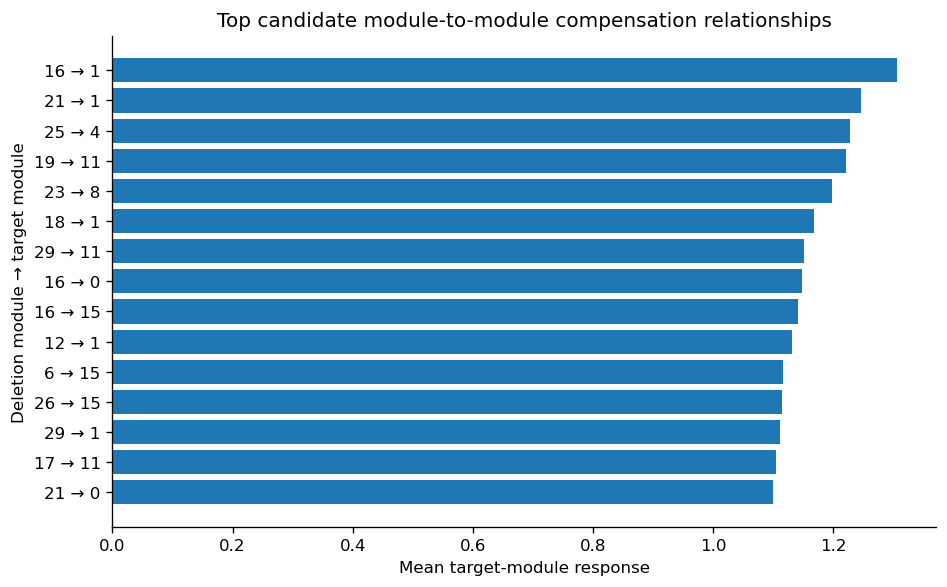

In [16]:
# ============================================================
# CELL 14: PLOT TOP POSITIVE COMPENSATION PAIRS
# ============================================================

top_plot = top_positive_pairs.head(15).copy()
top_plot["pair"] = top_plot["deletion_module"].astype(str) + " → " + top_plot["target_module"].astype(str)

plt.figure(figsize=(8, 5))
plt.barh(top_plot["pair"], top_plot["mean_response"])
plt.xlabel("Mean target-module response")
plt.ylabel("Deletion module → target module")
plt.title("Top candidate module-to-module compensation relationships")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [17]:
# ============================================================
# CELL 15: GENE-LEVEL FOLLOW-UP FOR ONE MODULE PAIR
# ============================================================

focus_deletion_module = 5
focus_target_module = 0

subset = module_avg_df[module_avg_df["deletion_module"] == focus_deletion_module].copy()
subset = subset[[focus_target_module]].rename(columns={focus_target_module: "target_response"})
subset = subset.sort_values("target_response", ascending=False)

subset.head(20)

,target_response
orf,
YHL023C,1.141271
YML103C,1.141177
YDR392W,1.129651
YPL215W,1.117926
YLR136C,1.095355
YPL030W,1.094513
YKL206C,1.091411
YKR003W,1.090913
YDR159W,1.084135


Pairwise module analysis reveals that genetic perturbation responses are structured at the level of specific module-to-module relationships rather than broad global activation of all chaperone-rich communities. Several modules, especially 1, 11, and 15, emerge as recurrent response modules, while chaperone-rich modules 0 and 4 show distinct and sometimes opposite behaviors. These results suggest that perturbation buffering in the yeast interactome is selective and modular, with different communities contributing differently to compensation.